# Policy-Frame-Titelannotation: CHN-LLM-Konsens und Ground-Truth-Abgleich

Dieses Notebook ist die CHN-Anpassung des bestehenden Workflows. Es verarbeitet drei unabhängige LLM-Annotationen und gleicht den daraus gebildeten Konsens mit `chn_ground_truth_full.csv` ab.

## Workflow
1. Drei LLM-Annotationen werden eingelesen.
2. Die LLM-Codes `2` (Mainframe) werden nach der Validierung zu `1` umcodiert.
3. Ein Frame gilt bei **mindestens 2 von 3 positiven Stimmen** als Konsens. Sowohl `2/3` als auch `3/3` werden übernommen.
4. Die gemeinsame Artikel-ID ist in allen vier Dateien `Filename`. Die Quelldateien werden nicht verändert.
5. Der LLM-Konsens wird mit `chn_ground_truth_full.csv` abgeglichen. Ein konsensuell erkannter Frame bleibt nur erhalten, wenn er auch in der Ground Truth positiv annotiert ist.
6. Konsensstärke (`2/3` oder `3/3`) und Einzelstimmen werden im Konsensprotokoll dokumentiert.
7. Alle erzeugten Dateien werden im Unterordner `chn_konsens_output` abgelegt.


In [9]:
from pathlib import Path
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 160)
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

print("Pandas:", pd.__version__)


Pandas: 2.3.3


## 1. Konfiguration

Die Eingabedateien liegen neben dem Notebook. `BASE_DIR` ist das Arbeitsverzeichnis des Notebooks. Das Ausgabeziel wird relativ dazu als `chn_konsens_output` angelegt.

> Hinweis: In Colab gibt es keine portable Python-Variable, die den Speicherort der `.ipynb`-Datei zuverlässig liefert. Deshalb muss das Notebook aus seinem Verzeichnis heraus ausgeführt werden; `Path.cwd()` repräsentiert dann den relativen Notebook-Ordner.


In [10]:
# ---------- Pfade ----------
BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "chn_konsens_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

LLM_FILES = [
    "chn_headlines_dataset_full_LLM_annotated_claude-sonnet-5.csv",
    "chn_headlines_dataset_full_LLM_annotated_gemini-3.6-flash.csv",
    "chn_headlines_dataset_full_LLM_annotated_GPT-5.6-Luna.csv",
]
GROUND_TRUTH_FILE = "chn_ground_truth_full.csv"

# ---------- Schlüssel / Metadaten ----------
# Die Originalspalten bleiben unverändert. Intern wird Filename auf article_id abgebildet.
ID_COLUMN = "article_id"
SOURCE_ID_COLUMN = "Filename"
TITLE_COLUMN = "Headline_GER"
LANGUAGE_COLUMN = "Language"

POLICY_FRAME_COLUMNS = [
    "Economic",
    "Capacity and resources",
    "Morality",
    "Fairness and equality",
    "Legality, constitutionality and jurisprudence",
    "Policy prescription and evaluation",
    "Crime and punishment",
    "Security and defense",
    "Health and safety",
    "Quality of life",
    "Cultural identity",
    "Public opinion",
    "Political",
    "External regulation and reputation",
]
FRAME_COLUMNS = POLICY_FRAME_COLUMNS

# ---------- Kodierung / Konsens ----------
LLM_VALID_VALUES = {0, 1, 2}
GROUND_TRUTH_VALID_VALUES = {0, 1}
VALUE_RECODE_MAP = {2: 1}
MIN_CONSENSUS_VOTES = 2
LLM_COUNT = 3
ACCEPTED_VOTE_COUNTS = {2, 3}

# ---------- Erwartete ID-Menge ----------
EXPECTED_ID_MIN = 1
EXPECTED_ID_MAX = 312

# ---------- Ausgabedateien ----------
OUTPUT_FILES = {
    "consensus": OUTPUT_DIR / "chn_01_llm_konsens.xlsx",
    "protocol": OUTPUT_DIR / "chn_02_konsensprotokoll.xlsx",
    "final": OUTPUT_DIR / "chn_03_finale_titelannotationen.xlsx",
    "removal": OUTPUT_DIR / "chn_04_streichungsprotokoll.xlsx",
    "statistics": OUTPUT_DIR / "chn_05_frame_statistik.xlsx",
    "plot": OUTPUT_DIR / "chn_05_frame_statistik.png",
    "summary": OUTPUT_DIR / "chn_06_zentrale_auswertung.txt",
}

llm_paths = [BASE_DIR / name for name in LLM_FILES]
ground_truth_path = BASE_DIR / GROUND_TRUTH_FILE

print("Basisverzeichnis:", BASE_DIR)
print("Ausgabeordner:", OUTPUT_DIR)


Basisverzeichnis: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/chn
Ausgabeordner: /Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/chn/chn_konsens_output


## 2. Einlesen und Validierung

Die CSV-Dateien werden mit einem echten CSV-Parser und `sep=';'` eingelesen. Dadurch bleiben korrekt quotierte mehrzeilige `Headline_GER`-Felder wie bei `chn_104` und `chn_136` erhalten.

Die Validierung bricht bewusst ab bei fehlenden Dateien, fehlenden Pflichtspalten, leeren oder doppelten IDs, unbekannten Frame-Codes oder inkonsistenten ID-Mengen.


In [11]:
def read_csv_table(path):
    return pd.read_csv(
        path,
        sep=";",
        quotechar='"',
        encoding="utf-8-sig",
        dtype={SOURCE_ID_COLUMN: "string"},
        keep_default_na=False,
    )


def prepare_frame_codes(df, valid_values, source_name):
    allowed = {int(v) for v in valid_values}
    result = df.copy()

    for frame in FRAME_COLUMNS:
        numeric = pd.to_numeric(result[frame], errors="raise")
        observed = set(numeric.astype(int).unique())
        invalid = sorted(observed - allowed)
        if invalid:
            raise ValueError(
                f"{source_name}: ungültige Werte in '{frame}': {invalid}. "
                f"Erlaubt: {sorted(allowed)}"
            )
        result[frame] = numeric.astype(int)
        for old, new in VALUE_RECODE_MAP.items():
            result[frame] = result[frame].replace(old, new)

    return result


def validate_table(df, source_name, valid_values):
    required = {SOURCE_ID_COLUMN, *FRAME_COLUMNS}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(f"{source_name}: fehlende Pflichtspalten: {missing}")

    result = df.copy()
    result[SOURCE_ID_COLUMN] = result[SOURCE_ID_COLUMN].astype(str).str.strip()

    if (result[SOURCE_ID_COLUMN] == "").any():
        raise ValueError(f"{source_name}: mindestens eine leere Filename-ID.")

    duplicates = result.loc[
        result[SOURCE_ID_COLUMN].duplicated(keep=False), SOURCE_ID_COLUMN
    ].unique().tolist()
    if duplicates:
        raise ValueError(f"{source_name}: doppelte Filename-IDs: {duplicates[:20]}")

    for frame in FRAME_COLUMNS:
        if result[frame].isna().any():
            raise ValueError(f"{source_name}: fehlende Werte in '{frame}'.")

    result = prepare_frame_codes(result, valid_values, source_name)
    return result.rename(columns={SOURCE_ID_COLUMN: ID_COLUMN})


missing_files = [str(p) for p in [*llm_paths, ground_truth_path] if not p.exists()]
if missing_files:
    raise FileNotFoundError(
        "Folgende Eingabedateien fehlen:\n" + "\n".join(missing_files)
    )

llm_raw = [read_csv_table(p) for p in llm_paths]
ground_truth_raw = read_csv_table(ground_truth_path)

llm_data = [
    validate_table(df, path.name, LLM_VALID_VALUES)
    for df, path in zip(llm_raw, llm_paths)
]
ground_truth = validate_table(
    ground_truth_raw,
    ground_truth_path.name,
    GROUND_TRUTH_VALID_VALUES,
)

print("Datei- und Schema-Prüfung erfolgreich.")
for path, df in zip(llm_paths, llm_data):
    print(f"LLM  {path.name}: {len(df)} Artikel")
print(f"GT   {ground_truth_path.name}: {len(ground_truth)} Artikel")
print(f"Frames: {len(FRAME_COLUMNS)}")


Datei- und Schema-Prüfung erfolgreich.
LLM  chn_headlines_dataset_full_LLM_annotated_claude-sonnet-5.csv: 312 Artikel
LLM  chn_headlines_dataset_full_LLM_annotated_gemini-3.6-flash.csv: 312 Artikel
LLM  chn_headlines_dataset_full_LLM_annotated_GPT-5.6-Luna.csv: 312 Artikel
GT   chn_ground_truth_full.csv: 312 Artikel
Frames: 14


## 3. ID-, Titel- und Metadatenkonsistenz


In [12]:
def id_set_report(dataframes, names):
    sets = [set(df[ID_COLUMN]) for df in dataframes]
    union_ids = set.union(*sets)
    common_ids = set.intersection(*sets)
    rows = []
    for name, ids in zip(names, sets):
        rows.append({
            "Datei": name,
            "Artikel": len(ids),
            "Fehlend_gegen_Union": len(union_ids - ids),
            "Zusätzlich_gegen_Schnittmenge": len(ids - common_ids),
        })
    return pd.DataFrame(rows), sets, union_ids, common_ids


all_sources = [*llm_data, ground_truth]
all_names = [p.name for p in [*llm_paths, ground_truth_path]]
id_report, id_sets, union_ids, common_ids = id_set_report(all_sources, all_names)

if any(s != id_sets[0] for s in id_sets[1:]):
    details = {
        name: {
            "fehlend": sorted(union_ids - ids)[:20],
            "zusätzlich": sorted(ids - common_ids)[:20],
        }
        for name, ids in zip(all_names, id_sets)
        if ids != id_sets[0]
    }
    raise ValueError(f"Die vier Dateien haben nicht dieselbe ID-Menge: {details}")

article_ids = list(llm_data[0][ID_COLUMN])
expected_ids = {f"chn_{i}" for i in range(EXPECTED_ID_MIN, EXPECTED_ID_MAX + 1)}
actual_ids = set(article_ids)

if actual_ids != expected_ids:
    raise ValueError(
        "Die erwartete ID-Menge chn_1 ... chn_312 stimmt nicht mit den Dateien überein. "
        f"Fehlend: {sorted(expected_ids - actual_ids)[:20]}; "
        f"zusätzlich: {sorted(actual_ids - expected_ids)[:20]}"
    )

metadata_mismatches = []
for col in [TITLE_COLUMN, LANGUAGE_COLUMN]:
    if all(col in df.columns for df in all_sources):
        ref = all_sources[0].set_index(ID_COLUMN)[col].fillna("").astype(str)
        for source_name, df in zip(all_names[1:], all_sources[1:]):
            other = df.set_index(ID_COLUMN)[col].fillna("").astype(str)
            mismatch_ids = ref.index[ref.ne(other)].tolist()
            for article_id in mismatch_ids:
                metadata_mismatches.append({
                    ID_COLUMN: article_id,
                    "Spalte": col,
                    "Referenzdatei": all_names[0],
                    "Vergleichsdatei": source_name,
                    "Referenzwert": ref.loc[article_id],
                    "Vergleichswert": other.loc[article_id],
                })

metadata_mismatches = pd.DataFrame(metadata_mismatches)

print("ID-Prüfung: OK")
print("Erwartete IDs: chn_1 ... chn_312")
print("Gemeinsame Artikel:", len(article_ids))
print("Metadatenabweichungen:", len(metadata_mismatches))
display(id_report)
if not metadata_mismatches.empty:
    display(metadata_mismatches.head(20))


ID-Prüfung: OK
Erwartete IDs: chn_1 ... chn_312
Gemeinsame Artikel: 312
Metadatenabweichungen: 0


,Datei,Artikel,Fehlend_gegen_Union,Zusätzlich_gegen_Schnittmenge
0,chn_headlines_dataset_full_LLM_annotated_claude-sonnet-5.csv,312,0,0
1,chn_headlines_dataset_full_LLM_annotated_gemini-3.6-flash.csv,312,0,0
2,chn_headlines_dataset_full_LLM_annotated_GPT-5.6-Luna.csv,312,0,0
3,chn_ground_truth_full.csv,312,0,0


## 4. LLM-Konsens

Nach der Umcodierung `2 → 1` wird pro Artikel und Frame die Zahl der positiven LLM-Stimmen berechnet.

- `0/3` oder `1/3` → kein Konsens
- `2/3` → Konsens
- `3/3` → Konsens

Die Einzelstimmen werden im Protokoll erhalten, damit jede Konsensentscheidung nachvollziehbar bleibt.


In [13]:
llm_indexed = [df.set_index(ID_COLUMN).loc[article_ids] for df in llm_data]

llm_names = [
    "Claude Sonnet 5",
    "Gemini 3.6 Flash",
    "GPT-5.6 Luna",
]

base_metadata = llm_indexed[0][
    [c for c in [TITLE_COLUMN, LANGUAGE_COLUMN] if c in llm_indexed[0].columns]
].copy()

vote_counts = pd.DataFrame(index=article_ids)
consensus_binary = pd.DataFrame(index=article_ids)
protocol_records = []

for frame in FRAME_COLUMNS:
    votes_by_model = [df[frame].astype(int) for df in llm_indexed]
    positive_votes = sum((s == 1).astype(int) for s in votes_by_model)
    consensus = positive_votes.isin(ACCEPTED_VOTE_COUNTS).astype(int)

    vote_counts[frame] = positive_votes.astype(int)
    consensus_binary[frame] = consensus

    for article_id in article_ids:
        votes = int(positive_votes.loc[article_id])
        row = {
            ID_COLUMN: article_id,
            TITLE_COLUMN: base_metadata.loc[article_id, TITLE_COLUMN],
            "Frame": frame,
            "Positive_Stimmen": votes,
            "Übereinstimmung": f"{votes}/{LLM_COUNT}",
            "Konsens_übernommen": int(consensus.loc[article_id]),
            "Konsensstatus": (
                f"übernommen ({votes}/{LLM_COUNT})"
                if consensus.loc[article_id]
                else f"nicht übernommen ({votes}/{LLM_COUNT})"
            ),
        }
        for model_name, series in zip(llm_names, votes_by_model):
            row[f"Binärwert_{model_name}"] = int(series.loc[article_id])
        protocol_records.append(row)

consensus_protocol = pd.DataFrame(protocol_records)
consensus_wide = base_metadata.join(consensus_binary).reset_index()
consensus_positive_long = consensus_protocol[
    consensus_protocol["Konsens_übernommen"] == 1
].copy()

agreement_summary = (
    consensus_protocol.groupby(["Frame", "Übereinstimmung"], as_index=False)
    .size()
    .rename(columns={"size": "Artikel_Frame_Paare"})
)

print("Verarbeitete Artikel:", len(article_ids))
print(
    "Konsensuelle positive Artikel-Frame-Paare:",
    int(consensus_binary.to_numpy().sum()),
)
display(agreement_summary)


Verarbeitete Artikel: 312
Konsensuelle positive Artikel-Frame-Paare: 680


,Frame,Übereinstimmung,Artikel_Frame_Paare
0,Capacity and resources,0/3,263
1,Capacity and resources,1/3,34
2,Capacity and resources,2/3,7
3,Capacity and resources,3/3,8
4,Crime and punishment,0/3,252
5,Crime and punishment,1/3,15
6,Crime and punishment,2/3,11
7,Crime and punishment,3/3,34
8,Cultural identity,0/3,249
9,Cultural identity,1/3,22


## 5. Abgleich mit der CHN Ground Truth

`chn_ground_truth_full.csv` übernimmt hier exakt die Rolle der bisherigen SemEval-Ground-Truth. Ein Frame aus dem LLM-Konsens wird nur dann in die finale Titelannotation übernommen, wenn der entsprechende Frame in der Ground Truth ebenfalls `1` ist.


In [14]:
gt_indexed = ground_truth.set_index(ID_COLUMN).loc[article_ids]

removal_records = []
final_binary = consensus_binary.copy()

for frame in FRAME_COLUMNS:
    gt_positive = gt_indexed[frame].astype(int).eq(1)
    llm_consensus = consensus_binary[frame].astype(int).eq(1)

    remove_mask = llm_consensus & ~gt_positive
    keep_mask = llm_consensus & gt_positive
    final_binary.loc[remove_mask, frame] = 0

    for article_id in article_ids:
        if not llm_consensus.loc[article_id]:
            continue

        votes = int(vote_counts.loc[article_id, frame])
        kept = bool(keep_mask.loc[article_id])

        removal_records.append({
            ID_COLUMN: article_id,
            TITLE_COLUMN: base_metadata.loc[article_id, TITLE_COLUMN],
            "Frame": frame,
            "Positive_Stimmen": votes,
            "Übereinstimmung": f"{votes}/{LLM_COUNT}",
            "Ground_Truth_Binärwert": int(gt_indexed.loc[article_id, frame]),
            "Behalten": int(kept),
            "Grund": (
                "LLM-Konsens vorhanden und Frame in Ground Truth vorhanden"
                if kept
                else "LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
            ),
        })

removal_protocol = pd.DataFrame(removal_records)
final_title_annotations = base_metadata.join(final_binary).reset_index()

consensus_pairs = int(consensus_binary.to_numpy().sum())
kept_pairs = int(final_binary.to_numpy().sum())
removed_pairs = consensus_pairs - kept_pairs

print("LLM-Konsens-Paare:", consensus_pairs)
print("Nach Ground-Truth-Abgleich behalten:", kept_pairs)
print("Gestrichen:", removed_pairs)
display(removal_protocol.head(20))


LLM-Konsens-Paare: 680
Nach Ground-Truth-Abgleich behalten: 467
Gestrichen: 213


,article_id,Headline_GER,Frame,Positive_Stimmen,Übereinstimmung,Ground_Truth_Binärwert,Behalten,Grund
0,chn_21,Die japanische Fabrik von TSMC wird voraussichtlich im Oktober mit der Installation beginnen und Ende nächsten Jahres mit der Massenproduktion beginnen,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
1,chn_27,S&P stuft die Kreditwürdigkeit Russlands angesichts des Krieges zwischen Russland und der Ukraine auf „Junk“ herab,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
2,chn_35,Das Vereinigte Königreich und die EU leiten gleichzeitig kartellrechtliche Ermittlungen gegen Facebook ein,Economic,2,2/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
3,chn_39,Das Gesamtwachstum der Einzelhandelsumsätze in China erreichte im Oktober dieses Jahres einen neuen Höchststand,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
4,chn_46,Die US-Beschränkungen für den Export von Chip-Werkzeugen nach China stehen kurz vor dem Abschluss,Economic,3,3/3,0,0,"LLM-Konsens vorhanden, Frame fehlt in Ground Truth"
5,chn_55,Chinas Fertigungsindustrie hat im September Fahrt aufgenommen,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
6,chn_56,"320 glückliche Unternehmen wurden mit Gold ausgezeichnet. Manpower Bank: Fast 60 % der Büroangestellten sind der Meinung, dass ihr aktueller Job unzufrieden...",Economic,2,2/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
7,chn_57,"Russland plant, Schulden für behinderte Soldaten zu begleichen",Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
8,chn_74,"Der CEO von Goldman Sachs warnt: Eine hartnäckige Inflation könnte die Fed dazu zwingen, die Zinsen weiter anzuheben",Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden
9,chn_77,Jugendliche aus Los Angeles County können bezahlte Praktikumsmöglichkeiten bei staatlichen und privaten Unternehmen erhalten,Economic,3,3/3,1,1,LLM-Konsens vorhanden und Frame in Ground Truth vorhanden


## 6. Frame-Statistik

Ausgewiesen werden die positiven Frame-Anteile für die drei einzelnen LLM-Annotationen nach `2 → 1`, den LLM-Konsens, die CHN Ground Truth und die finale Titelannotation nach dem Ground-Truth-Abgleich.


,Frame,Claude Sonnet 5 positive,Claude Sonnet 5 Anteil,Gemini 3.6 Flash positive,Gemini 3.6 Flash Anteil,GPT-5.6 Luna positive,GPT-5.6 Luna Anteil,LLM-Konsens positive,LLM-Konsens Anteil,Ground Truth positive,Ground Truth Anteil,Finale Titelannotation positive,Finale Titelannotation Anteil
0,Economic,53,0.169872,85,0.272436,56,0.179487,61,0.195513,86,0.275641,49,0.157051
1,Capacity and resources,14,0.044872,45,0.144231,13,0.041667,15,0.048077,89,0.285256,11,0.035256
2,Morality,18,0.057692,23,0.073718,15,0.048077,19,0.060897,33,0.105769,16,0.051282
3,Fairness and equality,30,0.096154,38,0.121795,22,0.070513,28,0.089744,39,0.125000,15,0.048077
4,"Legality, constitutionality and jurisprudence",30,0.096154,44,0.141026,38,0.121795,34,0.108974,66,0.211538,9,0.028846
5,Policy prescription and evaluation,31,0.099359,104,0.333333,65,0.208333,65,0.208333,144,0.461538,55,0.176282
6,Crime and punishment,44,0.141026,55,0.176282,40,0.128205,45,0.144231,77,0.246795,40,0.128205
7,Security and defense,62,0.198718,74,0.237179,47,0.150641,60,0.192308,102,0.326923,51,0.163462
8,Health and safety,56,0.179487,75,0.240385,53,0.169872,61,0.195513,54,0.173077,40,0.128205
9,Quality of life,12,0.038462,27,0.086538,4,0.012821,8,0.025641,57,0.182692,6,0.019231


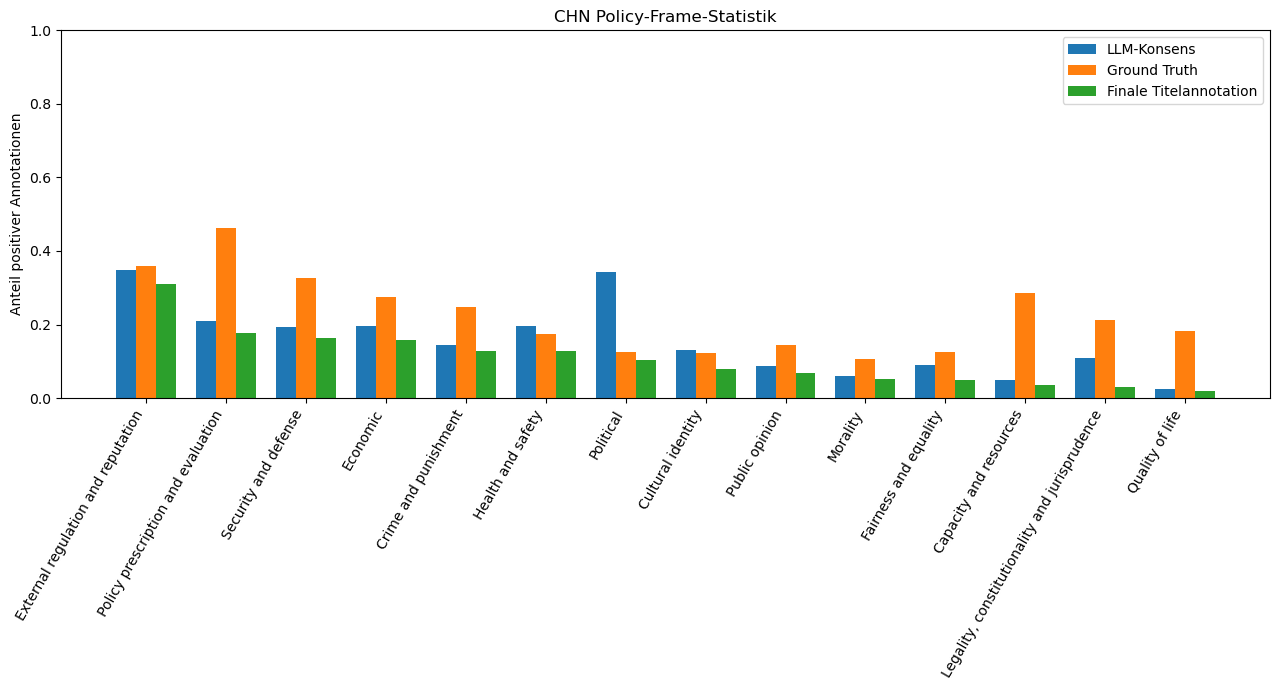

In [15]:
statistics_rows = []

for frame in FRAME_COLUMNS:
    row = {"Frame": frame}

    for model_name, df in zip(llm_names, llm_indexed):
        row[f"{model_name} positive"] = int(df[frame].sum())
        row[f"{model_name} Anteil"] = float(df[frame].mean())

    row["LLM-Konsens positive"] = int(consensus_binary[frame].sum())
    row["LLM-Konsens Anteil"] = float(consensus_binary[frame].mean())

    row["Ground Truth positive"] = int(gt_indexed[frame].sum())
    row["Ground Truth Anteil"] = float(gt_indexed[frame].mean())

    row["Finale Titelannotation positive"] = int(final_binary[frame].sum())
    row["Finale Titelannotation Anteil"] = float(final_binary[frame].mean())

    statistics_rows.append(row)

frame_statistics = pd.DataFrame(statistics_rows)
display(frame_statistics)

plot_df = frame_statistics[
    ["Frame", "LLM-Konsens Anteil", "Ground Truth Anteil", "Finale Titelannotation Anteil"]
].sort_values("Finale Titelannotation Anteil", ascending=False)

plt.figure(figsize=(13, 7))
x = np.arange(len(plot_df))
width = 0.25
plt.bar(x - width, plot_df["LLM-Konsens Anteil"], width, label="LLM-Konsens")
plt.bar(x, plot_df["Ground Truth Anteil"], width, label="Ground Truth")
plt.bar(x + width, plot_df["Finale Titelannotation Anteil"], width, label="Finale Titelannotation")
plt.xticks(x, plot_df["Frame"], rotation=60, ha="right")
plt.ylabel("Anteil positiver Annotationen")
plt.title("CHN Policy-Frame-Statistik")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FILES["plot"], dpi=200, bbox_inches="tight")
plt.show()


## 7. Zentrale Auswertung und Qualitätsbericht


In [16]:
agreement_counts = consensus_protocol["Übereinstimmung"].value_counts().to_dict()

summary_lines = [
    "CHN Policy-Frame-Titelannotation – zentrale Auswertung",
    "=" * 60,
    "",
    f"Artikel: {len(article_ids)}",
    f"LLM-Modelle: {LLM_COUNT}",
    "Konsensregel: mindestens 2 von 3 positiven Stimmen",
    "LLM-Umcodierung: 2 -> 1",
    "Ground Truth: chn_ground_truth_full.csv",
    "",
    f"Konsensuelle positive Artikel-Frame-Paare: {consensus_pairs}",
    f"Davon 2/3: {agreement_counts.get('2/3', 0)}",
    f"Davon 3/3: {agreement_counts.get('3/3', 0)}",
    f"Nach Ground-Truth-Abgleich behalten: {kept_pairs}",
    f"Nach Ground-Truth-Abgleich gestrichen: {removed_pairs}",
    f"Metadatenabweichungen zwischen Dateien: {len(metadata_mismatches)}",
    "",
    "Finale positive Frames nach Frame:",
]

for frame in FRAME_COLUMNS:
    summary_lines.append(
        f"  - {frame}: {int(final_binary[frame].sum())}"
    )

summary_text = "\n".join(summary_lines) + "\n"
OUTPUT_FILES["summary"].write_text(summary_text, encoding="utf-8")
print(summary_text)


CHN Policy-Frame-Titelannotation – zentrale Auswertung

Artikel: 312
LLM-Modelle: 3
Konsensregel: mindestens 2 von 3 positiven Stimmen
LLM-Umcodierung: 2 -> 1
Ground Truth: chn_ground_truth_full.csv

Konsensuelle positive Artikel-Frame-Paare: 680
Davon 2/3: 271
Davon 3/3: 409
Nach Ground-Truth-Abgleich behalten: 467
Nach Ground-Truth-Abgleich gestrichen: 213
Metadatenabweichungen zwischen Dateien: 0

Finale positive Frames nach Frame:
  - Economic: 49
  - Capacity and resources: 11
  - Morality: 16
  - Fairness and equality: 15
  - Legality, constitutionality and jurisprudence: 9
  - Policy prescription and evaluation: 55
  - Crime and punishment: 40
  - Security and defense: 51
  - Health and safety: 40
  - Quality of life: 6
  - Cultural identity: 25
  - Public opinion: 21
  - Political: 32
  - External regulation and reputation: 97



## 8. Dateien speichern

Die Ausgabedateien erhalten die vereinbarten Namen mit `chn_`-Präfix und werden ausschließlich im Unterordner `chn_konsens_output` gespeichert.


In [17]:
# 01 – LLM-Konsens (breites Format)
consensus_wide.to_excel(OUTPUT_FILES["consensus"], index=False)

# 02 – vollständiges Konsensprotokoll
with pd.ExcelWriter(OUTPUT_FILES["protocol"], engine="openpyxl") as writer:
    consensus_protocol.to_excel(writer, sheet_name="Konsensprotokoll", index=False)
    agreement_summary.to_excel(writer, sheet_name="Übereinstimmung", index=False)
    id_report.to_excel(writer, sheet_name="ID_Prüfung", index=False)
    if not metadata_mismatches.empty:
        metadata_mismatches.to_excel(
            writer, sheet_name="Metadatenabweichungen", index=False
        )

# 03 – finale Titelannotation
final_title_annotations.to_excel(OUTPUT_FILES["final"], index=False)

# 04 – Streichungsprotokoll
with pd.ExcelWriter(OUTPUT_FILES["removal"], engine="openpyxl") as writer:
    removal_protocol.to_excel(
        writer, sheet_name="Streichungsprotokoll", index=False
    )
    removed_summary = (
        removal_protocol[removal_protocol["Behalten"] == 0]
        .groupby("Frame", as_index=False)
        .size()
        .rename(columns={"size": "Gestrichene_Paare"})
    )
    removed_summary.to_excel(writer, sheet_name="Nach_Frame", index=False)

# 05 – Frame-Statistik
frame_statistics.to_excel(OUTPUT_FILES["statistics"], index=False)

print("\nErzeugte Dateien:")
for path in OUTPUT_FILES.values():
    if path.exists():
        print(f" - {path.name} ({path.stat().st_size:,} Bytes)")

display(Markdown(f"**Ausgabeordner:** `{OUTPUT_DIR.resolve()}`"))



Erzeugte Dateien:
 - chn_01_llm_konsens.xlsx (37,908 Bytes)
 - chn_02_konsensprotokoll.xlsx (443,032 Bytes)
 - chn_03_finale_titelannotationen.xlsx (37,677 Bytes)
 - chn_04_streichungsprotokoll.xlsx (67,511 Bytes)
 - chn_05_frame_statistik.xlsx (6,854 Bytes)
 - chn_05_frame_statistik.png (235,671 Bytes)
 - chn_06_zentrale_auswertung.txt (910 Bytes)


**Ausgabeordner:** `/Users/Familie/Documents/Uni_Regensburg/A_Digital_Humanities/2SE_SS26/Natural_Language_Engineering/projekt/frame_detect_NLP/Y_additional_dataset/5_konsens_bildung/chn/chn_konsens_output`

## 9. Abschließende Integritätsprüfung


In [18]:
assert len(consensus_wide) == 312
assert len(final_title_annotations) == 312
assert set(final_title_annotations[ID_COLUMN]) == expected_ids
assert all(frame in final_title_annotations.columns for frame in FRAME_COLUMNS)
assert set(final_title_annotations[FRAME_COLUMNS].to_numpy().ravel()).issubset({0, 1})
assert all(path.exists() for path in OUTPUT_FILES.values())

print("✓ 312 Artikel vorhanden")
print("✓ chn_1 ... chn_312 vollständig und eindeutig")
print("✓ 14 Frame-Spalten vorhanden")
print("✓ Finale Frame-Werte ausschließlich 0/1")
print("✓ Alle vereinbarten Ausgabedateien vorhanden")
print("\nWorkflow erfolgreich abgeschlossen.")


✓ 312 Artikel vorhanden
✓ chn_1 ... chn_312 vollständig und eindeutig
✓ 14 Frame-Spalten vorhanden
✓ Finale Frame-Werte ausschließlich 0/1
✓ Alle vereinbarten Ausgabedateien vorhanden

Workflow erfolgreich abgeschlossen.
